# Data Preprocessing
This notebook handles the cleaning and preprocessing of the customer data.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from datetime import datetime

# Configuration
INPUT_FILE = 'data/customer_info.csv'
OUTPUT_FILE = 'data/customer_info_cleaned.csv'
CURRENT_YEAR = 2025

## 1. Load Data

In [2]:
df = pd.read_csv(INPUT_FILE)
print(f"Data loaded. Shape: {df.shape}")
df.head()

Data loaded. Shape: (16978, 25)


,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,11259,Louis Huffman,male,08/22/1948 05:06 AM,0.0,2.0,2.0,3.0,6238.0,818.0,...,1039.0,361.0,457.0,1520.0,210.0,0.623414,2000.0,917650.0,38.683897,-9.172942
1,6538,Msc. Noel Ward,male,02/12/1967 07:51 PM,2.0,1.0,3.0,3.0,4188.0,1048.0,...,1913.0,562.0,67.0,957.0,92.0,0.555637,2017.0,906928.0,38.790490,-9.115064
2,14274,Bsc. Scott Giordano,male,04/10/1986 05:10 PM,0.0,0.0,1.0,1.0,25269.0,4047.0,...,303.0,724.0,442.0,1213.0,85.0,0.259248,2014.0,958107.0,38.775609,-9.112610
3,7796,William Lacy,male,01/03/1999 01:47 AM,0.0,1.0,1.0,3.0,8292.0,1524.0,...,1877.0,560.0,1028.0,1005.0,169.0,0.419730,2024.0,967864.0,38.736641,-9.158548
4,4521,Bsc. Nathan Minor,male,10/21/1957 07:34 AM,3.0,1.0,2.0,3.0,43692.0,3718.0,...,3093.0,1635.0,868.0,745.0,345.0,0.428821,2004.0,971603.0,38.726597,-9.109803


### 1.1 Check for Duplicates

In [3]:
# Check for duplicates
print(f"Duplicates found: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

Duplicates found: 0
Shape after removing duplicates: (16978, 25)


### 1.2 Descriptive Statistics

In [4]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,16978.0,NaN,NaN,NaN,9981.332195,5781.604623,1.0,4973.25,9950.5,14999.75,20000.0
customer_name,16978,16850,Robert Davis,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_gender,16978,2,female,8580,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_birthdate,16910,16902,08/14/1975 01:23 AM,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kids_home,16893.0,NaN,NaN,NaN,1.639792,1.529161,0.0,0.0,1.0,3.0,11.0
teens_home,16910.0,NaN,NaN,NaN,1.085571,0.94828,0.0,0.0,1.0,2.0,5.0
number_complaints,16927.0,NaN,NaN,NaN,1.103917,0.920515,0.0,0.0,1.0,2.0,7.0
distinct_stores_visited,16808.0,NaN,NaN,NaN,1.984293,1.247115,1.0,1.0,2.0,2.0,10.0
lifetime_spend_groceries,16978.0,NaN,NaN,NaN,26920.981034,19734.997961,10.0,11344.5,20783.5,40250.25,128132.0
lifetime_spend_electronics,16978.0,NaN,NaN,NaN,2858.417069,2404.063138,0.0,1269.0,2370.0,3573.75,17407.0


## 2. Categorize Features
Identify categorical and numerical features.

In [5]:
# Explicit Feature Categorization by Context

categorical_cols = [
    # Demographics
    'customer_name', 'customer_gender', 'customer_birthdate',
    # Behavioral
    'loyalty_card_number'
]

numerical_cols = [
    # Demographics
    'kids_home', 'teens_home', 'latitude', 'longitude',
    
    # Spending
    'lifetime_spend_groceries', 'lifetime_spend_electronics', 
    'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks',
    'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat',
    'lifetime_spend_fish', 'lifetime_spend_hygiene',
    'lifetime_spend_videogames', 'lifetime_spend_petfood',
    
    # Behavioral
    'number_complaints', 'distinct_stores_visited', 'typical_hour', 
    'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion', 
    'year_first_transaction'
]

print("Categorical Features:", categorical_cols)
print("Numerical Features:", numerical_cols)

Categorical Features: ['customer_name', 'customer_gender', 'customer_birthdate', 'loyalty_card_number']
Numerical Features: ['kids_home', 'teens_home', 'latitude', 'longitude', 'lifetime_spend_groceries', 'lifetime_spend_electronics', 'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene', 'lifetime_spend_videogames', 'lifetime_spend_petfood', 'number_complaints', 'distinct_stores_visited', 'typical_hour', 'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion', 'year_first_transaction']


### 2.1 Exploratory Analysis (Pre-cleaning)

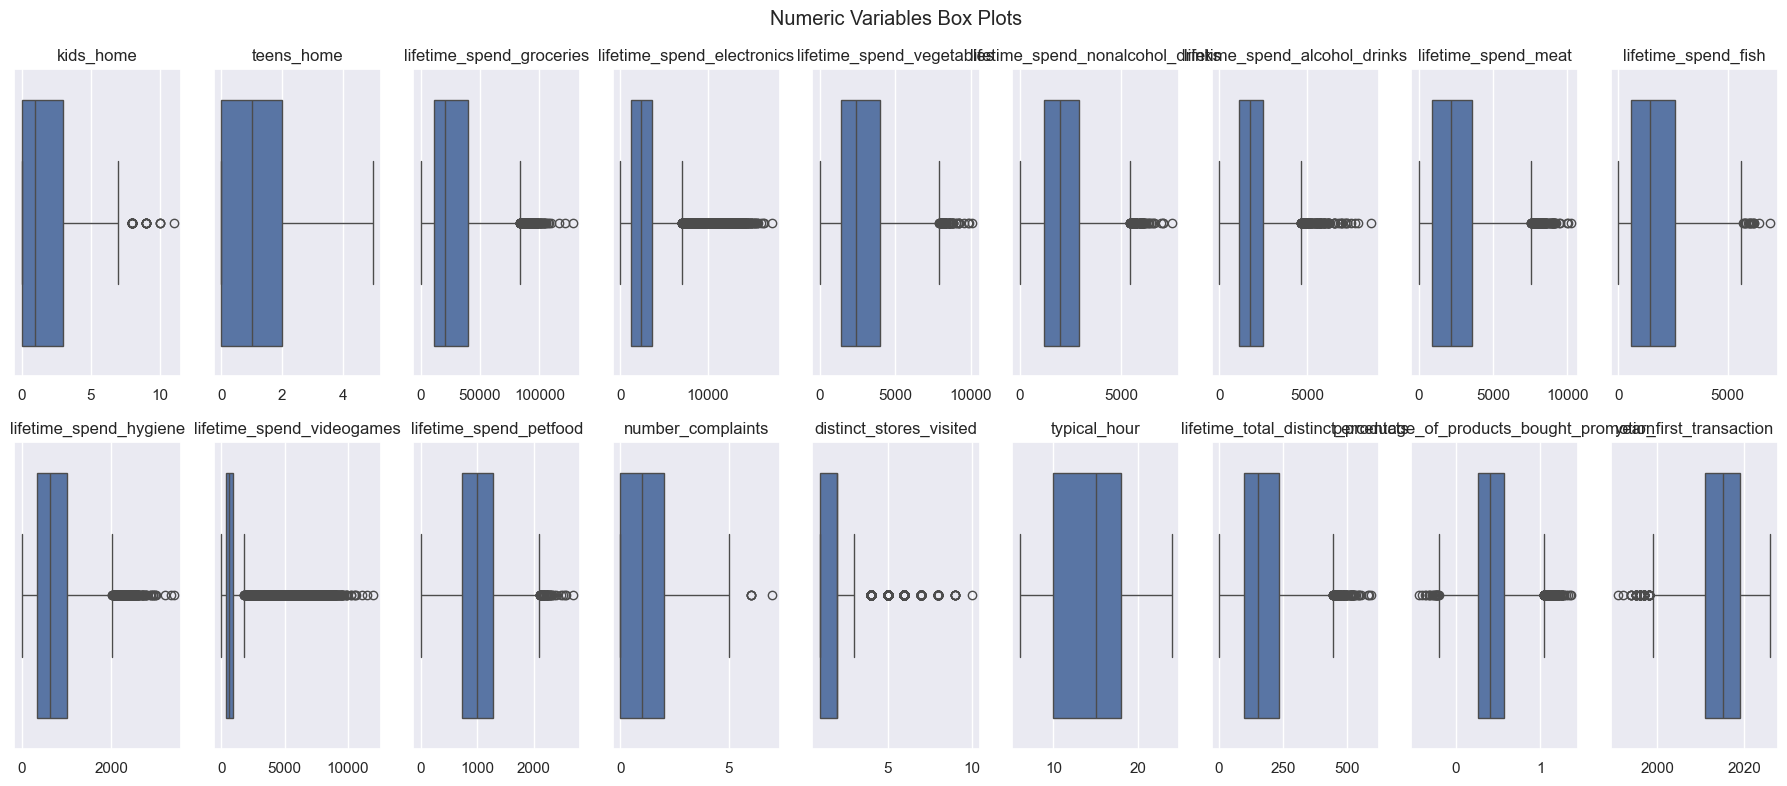

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

def plot_multiple_boxplots(data, feats, title="Numeric Variables Box Plots", figsize=(18, 8)):
    from math import ceil
    fig, axes = plt.subplots(2, ceil(len(feats) / 2), figsize=figsize)
    for ax, feat in zip(axes.flatten(), feats):
        if feat in data.columns:
            sns.boxplot(x=data[feat], ax=ax)
            ax.set_title(feat)
            ax.set_xlabel("")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Use numerical_cols for plotting, filtering out location data if desired
plot_cols = [c for c in numerical_cols if 'latitude' not in c and 'longitude' not in c]
plot_multiple_boxplots(df, plot_cols)

## 3. Handle Missing Values

In [7]:
df_clean = df.copy()

# Impute specific columns with Mode
for col in ['kids_home', 'teens_home', 'typical_hour']:
    if col in df_clean.columns:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)

# Impute spending and complaints with 0 (assumption: null = 0)
zero_impute_cols = [
    'number_complaints', 'distinct_stores_visited', 
    'lifetime_spend_groceries', 'lifetime_spend_electronics', 
    'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks', 
    'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat', 
    'lifetime_spend_fish', 'lifetime_spend_hygiene', 
    'lifetime_spend_videogames', 'lifetime_spend_petfood'
]

for col in zero_impute_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

# Check if any missing values remain (except birthdate/loyalty which we handle next)
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

customer_birthdate       68
loyalty_card_number    3143
dtype: int64


## 3.1 Outlier Handling (IQR Method)

In [8]:
def cap_outliers(data, feats, multiplier=3.0):
    df_capped = data.copy()
    q25 = df_capped[feats].quantile(0.25)
    q75 = df_capped[feats].quantile(0.75)
    iqr = (q75 - q25)
    upper_lim = q75 + multiplier * iqr
    lower_lim = q25 - multiplier * iqr
    
    for col in feats:
        if col in df_capped.columns:
            df_capped[col] = np.where(df_capped[col] > upper_lim[col], upper_lim[col], df_capped[col])
            df_capped[col] = np.where(df_capped[col] < lower_lim[col], lower_lim[col], df_capped[col])
            
    print(f'Outliers capped at {multiplier}x IQR thresholds.')
    return df_capped

# Apply IQR capping on spending columns mainly
spending_cols = [c for c in numerical_cols if 'lifetime_spend' in c]
if spending_cols:
    # Using 3.0 multiplier for capping based on analysis
    df_clean = cap_outliers(df_clean, spending_cols, multiplier=3.0)
    print('Shape after outlier capping:', df_clean.shape)


Outliers capped at 3.0x IQR thresholds.
Shape after outlier capping: (16978, 25)


Shape after outlier removal: (16978, 25)


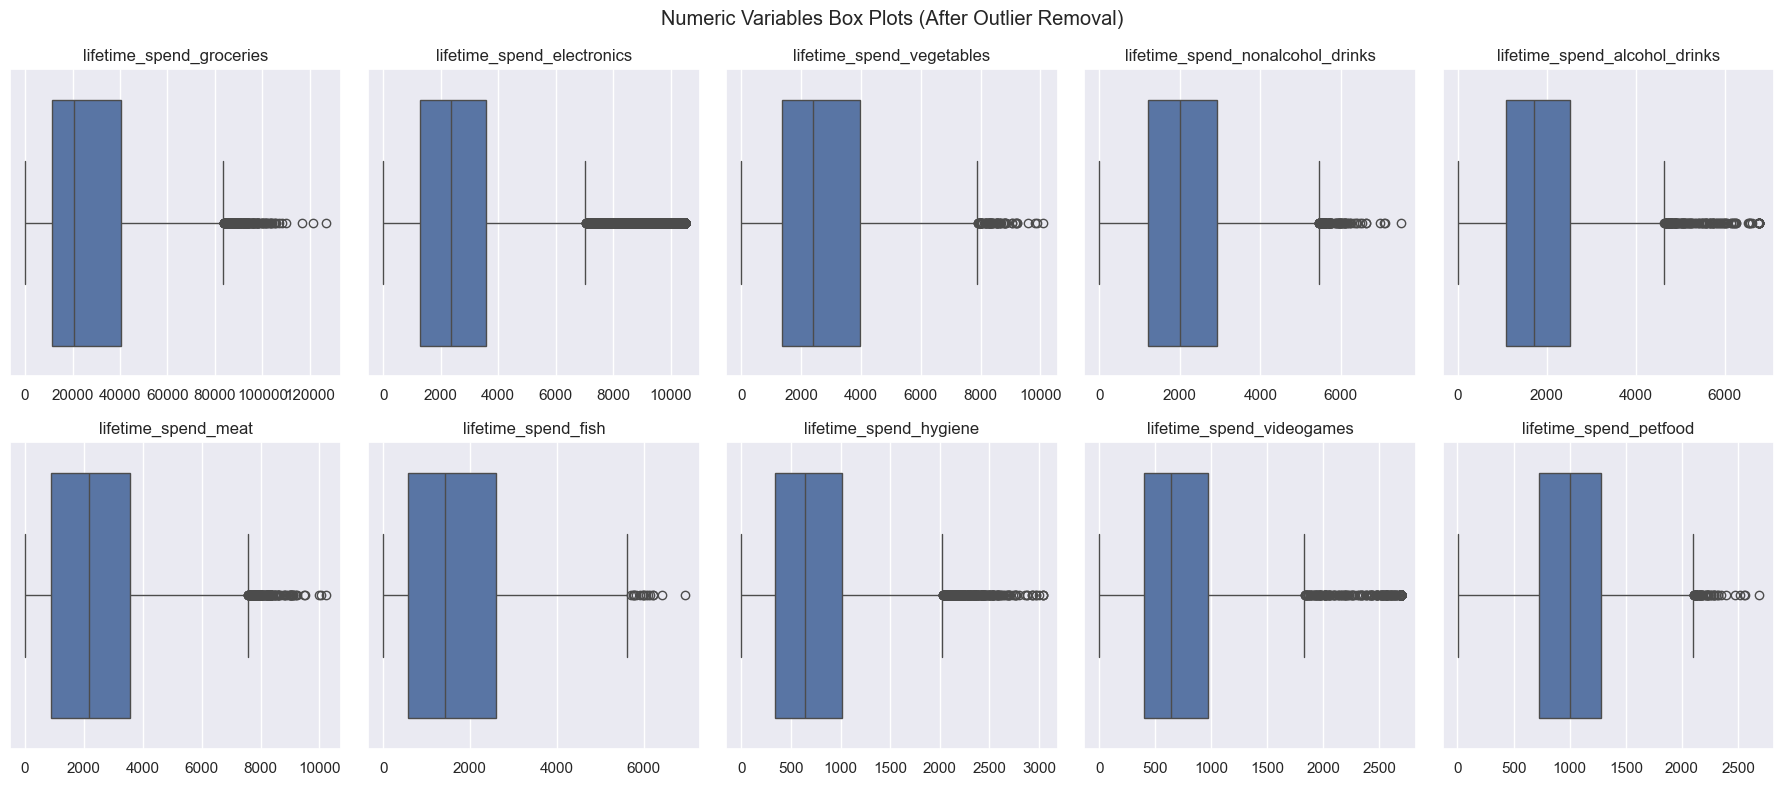

In [9]:

# Visualize data after outlier removal
print("Shape after outlier removal:", df_clean.shape)
plot_multiple_boxplots(df_clean, spending_cols, title="Numeric Variables Box Plots (After Outlier Removal)")

## 4. Feature Engineering

In [10]:
df_eng = df_clean.copy()

# 4.1 Age from Birthdate
def calculate_age(birthdate_str):
    if pd.isna(birthdate_str):
        return np.nan
    try:
        dt = datetime.strptime(birthdate_str, '%m/%d/%Y %I:%M %p')
        return CURRENT_YEAR - dt.year
    except:
        return np.nan

if 'customer_birthdate' in df_eng.columns:
    df_eng['Age'] = df_eng['customer_birthdate'].apply(calculate_age)
    df_eng['Age'] = df_eng['Age'].fillna(df_eng['Age'].median())

# 4.2 Loyalty Card Feature
if 'loyalty_card_number' in df_eng.columns:
    df_eng['has_loyalty_card'] = df_eng['loyalty_card_number'].apply(lambda x: 0 if pd.isna(x) else 1)

# 4.3 Drop unused columns
cols_to_drop = ['customer_id', 'customer_name', 'customer_birthdate', 'loyalty_card_number']
df_eng = df_eng.drop(columns=cols_to_drop, errors='ignore')

df_eng.head()

,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,...,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,latitude,longitude,Age,has_loyalty_card
0,male,0.0,2.0,2.0,3.0,6238.0,818.0,18.0,1553.0,1479.0,...,361.0,457.0,1520.0,210.0,0.623414,2000.0,38.683897,-9.172942,77.0,1
1,male,2.0,1.0,3.0,3.0,4188.0,1048.0,14.0,2060.0,1549.0,...,562.0,67.0,957.0,92.0,0.555637,2017.0,38.790490,-9.115064,58.0,1
2,male,0.0,0.0,1.0,1.0,25269.0,4047.0,12.0,4905.0,2357.0,...,724.0,442.0,1213.0,85.0,0.259248,2014.0,38.775609,-9.112610,39.0,1
3,male,0.0,1.0,1.0,3.0,8292.0,1524.0,15.0,2281.0,650.0,...,560.0,1028.0,1005.0,169.0,0.419730,2024.0,38.736641,-9.158548,26.0,1
4,male,3.0,1.0,2.0,3.0,43692.0,3718.0,10.0,6068.0,3014.0,...,1635.0,868.0,745.0,345.0,0.428821,2004.0,38.726597,-9.109803,68.0,1


### 4.2 Correlation Analysis

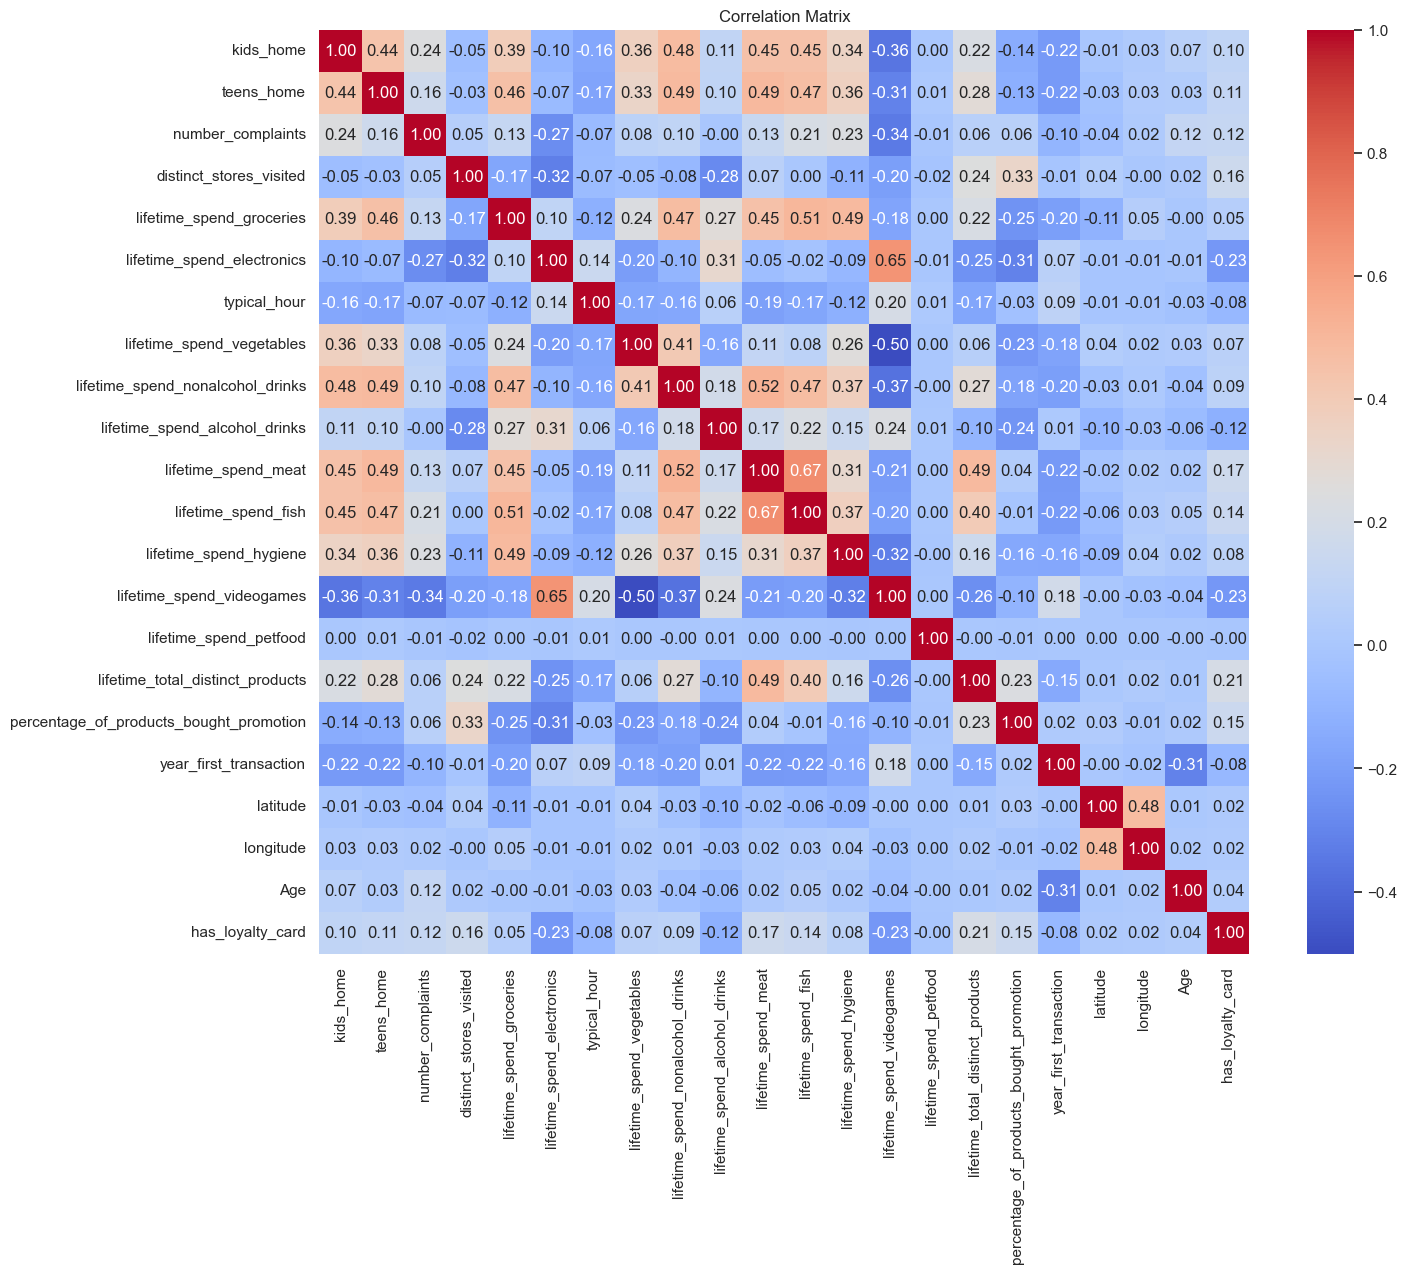

In [11]:
corr_matrix = df_eng.corr(numeric_only=True)
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 5. Encoding and Scaling

In [12]:
df_proc = df_eng.copy()

# 5.1 One-Hot Encoding
# We check specific categorical columns we know need encoding
if 'customer_gender' in categorical_cols and 'customer_gender' in df_proc.columns:
    df_proc = pd.get_dummies(df_proc, columns=['customer_gender'], drop_first=True)

# 5.2 Scaling
vars_to_scale = []

# Add defined numerical columns
for col in numerical_cols:
    if col in df_proc.columns:
        vars_to_scale.append(col)

# Add engineered numerical feature 'Age'
if 'Age' in df_proc.columns:
    vars_to_scale.append('Age')
    
# Add engineered feature 'has_loyalty_card' (binary, treated as numeric for scaling in this pipeline)
if 'has_loyalty_card' in df_proc.columns:
    vars_to_scale.append('has_loyalty_card')

print(f"Features selected for scaling ({len(vars_to_scale)}):", vars_to_scale)

scaler = StandardScaler()
df_proc[vars_to_scale] = scaler.fit_transform(df_proc[vars_to_scale])

print("Final shape:", df_proc.shape)
df_proc.head()

Features selected for scaling (22): ['kids_home', 'teens_home', 'latitude', 'longitude', 'lifetime_spend_groceries', 'lifetime_spend_electronics', 'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene', 'lifetime_spend_videogames', 'lifetime_spend_petfood', 'number_complaints', 'distinct_stores_visited', 'typical_hour', 'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion', 'year_first_transaction', 'Age', 'has_loyalty_card']
Final shape: (16978, 23)


,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,...,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,latitude,longitude,Age,has_loyalty_card,customer_gender_male
0,-1.072504,0.966614,0.976454,0.824209,-1.048082,-0.888171,0.700516,-0.670339,-0.565377,-0.261527,...,-0.546107,1.297567,0.408221,0.805903,-2.301895,-1.155593,-0.474619,1.269162,0.476631,True
1,0.238154,-0.090058,2.062127,0.824209,-1.151963,-0.786122,-0.135117,-0.387667,-0.505891,0.914368,...,-1.097906,-0.118290,-0.848041,0.521795,0.442280,1.683075,1.015009,0.205934,0.476631,True
2,-1.072504,-1.146731,-0.109220,-0.767580,-0.083709,0.544517,-0.552934,1.198533,0.180751,-1.234439,...,-0.567330,0.525510,-0.922565,-0.720614,-0.041986,1.286790,1.078169,-0.857295,0.476631,True
3,-1.072504,-0.090058,-0.109220,0.824209,-0.943998,-0.574923,0.073791,-0.264451,-1.269865,-0.739484,...,0.261782,0.002422,-0.028277,-0.047904,1.572235,0.249013,-0.104150,-1.584767,0.476631,True
4,0.893483,-0.090058,0.976454,0.824209,0.849855,0.398541,-0.970751,1.846951,0.739072,0.132438,...,0.035403,-0.651437,1.845471,-0.009794,-1.656207,-0.018443,1.150427,0.765528,0.476631,True


## 6. Save Output

In [13]:
df_proc.to_csv(OUTPUT_FILE, index=False)
print(f"Saved to {OUTPUT_FILE}")

Saved to data/customer_info_cleaned.csv
